<a href="https://colab.research.google.com/github/dang-ngan/Labor-Dynamics-Mapping-the-U.S.-Union-Wage-Gap-2000-2022-/blob/main/Union_Wage_Premium_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Union Wage Premium Analysis**


---


*This analysis utilizes a Weighted Least Squares (WLS) regression model to calculate adjusted union wage premiums, isolating the specific impact of union membership by controlling for key demographic variables including age, sex, race, education level, and geographic region.*

In [ ]:
!pip install statsmodels

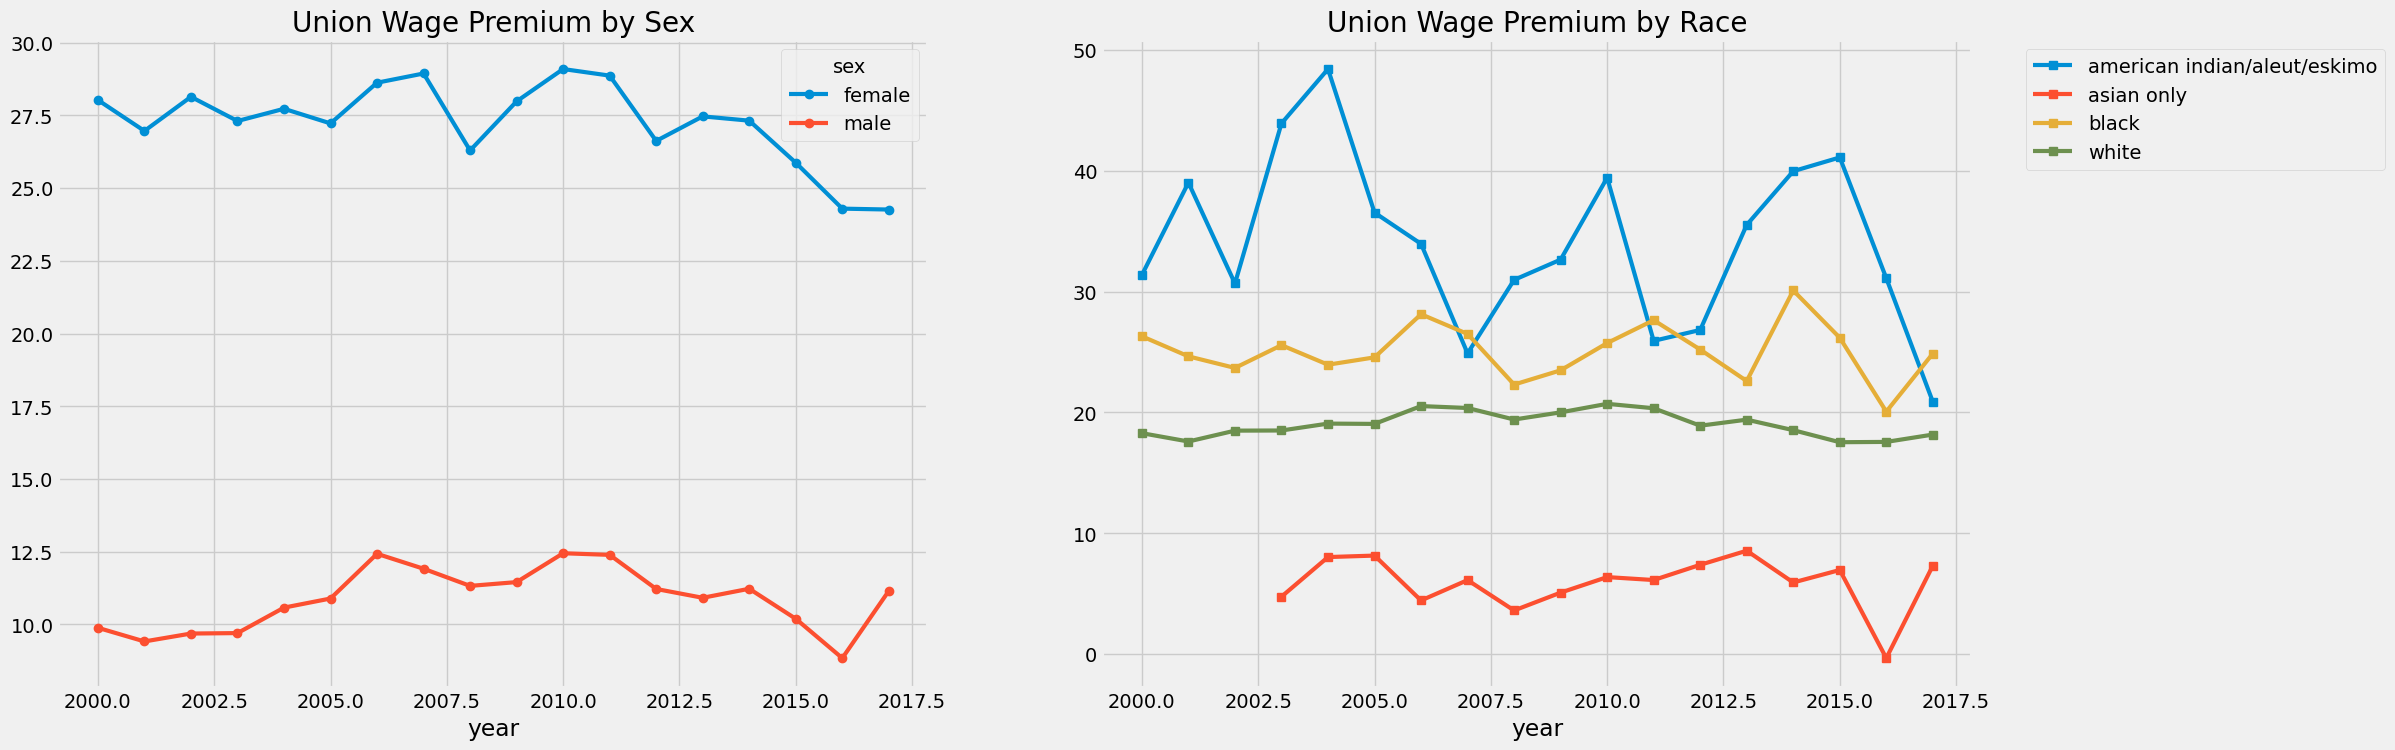

All files exported with Region column included in state map data.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

df = pd.read_csv('/content/data/union.csv', low_memory=False)

df['age'] = pd.to_numeric(df['age'].replace('under 1 year', 0), errors='coerce')
df['hourwage'] = pd.to_numeric(df['hourwage'], errors='coerce').replace(999.99, np.nan)
df['earnweek'] = pd.to_numeric(df['earnweek'], errors='coerce').replace(9999.99, np.nan)
df['uhrsworkt'] = pd.to_numeric(df['uhrsworkt'], errors='coerce')

df['hourly_wage'] = df['hourwage'].fillna(df['earnweek'] / df['uhrsworkt'])

df['union_str'] = df['union'].astype(str).str.lower()
df = df[df['union_str'] != 'niu'].copy()
df['is_union'] = df['union_str'].apply(lambda x: 1 if 'member' in x or 'covered' in x or 'yes' in x else 0)

df = df[(df['hourly_wage'] >= 2) & (df['hourly_wage'] <= 250)]
df = df.dropna(subset=['hourly_wage', 'is_union', 'wtfinl', 'sex', 'race', 'educ', 'age', 'statefip', 'region'])

top_races = df['race'].value_counts().nlargest(4).index.tolist()
df_main = df[df['race'].isin(top_races)].copy()

def get_weighted_mean(data):
    w_sum = data['wtfinl'].sum()
    if w_sum <= 0: return np.nan
    return (data['hourly_wage'] * data['wtfinl']).sum() / w_sum

def calc_premium_table(dataframe, group_col):
    stats = dataframe.groupby(['year', group_col, 'is_union'], group_keys=False).apply(get_weighted_mean, include_groups=False).unstack('is_union')
    for col in [0, 1]:
        if col not in stats.columns: stats[col] = np.nan
    stats.columns = ['Non_Union', 'Union']
    premium = ((stats['Union'] - stats['Non_Union']) / stats['Non_Union']) * 100
    return premium.unstack(group_col)

state_to_region = df[['statefip', 'region']].drop_duplicates().set_index('statefip')

state_stats = df.groupby(['year', 'statefip', 'is_union'], group_keys=False).apply(get_weighted_mean, include_groups=False).unstack('is_union')
state_stats.columns = ['Non_Union', 'Union']
state_stats['state_premium'] = ((state_stats['Union'] - state_stats['Non_Union']) / state_stats['Non_Union']) * 100
state_tidy = state_stats.reset_index()

state_tidy = state_tidy.merge(state_to_region, on='statefip', how='left')

sex_plot_data = calc_premium_table(df_main, 'sex')
race_plot_data = calc_premium_table(df_main, 'race')

results = []
for yr in sorted(df['year'].unique()):
    subset = df[df['year'] == yr]
    if subset['is_union'].nunique() == 2:
        try:
            model = smf.wls('np.log(hourly_wage) ~ is_union + age + C(sex) + C(race) + C(educ) + C(region)',
                            data=subset, weights=subset['wtfinl']).fit()
            results.append({'year': yr, 'Adjusted_Premium': (np.exp(model.params['is_union']) - 1) * 100})
        except: continue

reg_df = pd.DataFrame(results).set_index('year')

plt.style.use('fivethirtyeight')
fig, ax = plt.subplots(1, 2, figsize=(22, 8))

sex_plot_data.plot(ax=ax[0], marker='o', linewidth=3)
ax[0].set_title('Union Wage Premium by Sex')

race_plot_data.plot(ax=ax[1], marker='s', linewidth=3)
ax[1].set_title('Union Wage Premium by Race')
ax[1].legend(bbox_to_anchor=(1.05, 1))
plt.show()

reg_df.to_csv('union_adjusted_premium.csv')

sex_tidy = sex_plot_data.stack().reset_index().rename(columns={0: 'premium', 'sex': 'demographic_value'})
sex_tidy['category'] = 'Sex'
race_tidy = race_plot_data.stack().reset_index().rename(columns={0: 'premium', 'race': 'demographic_value'})
race_tidy['category'] = 'Race'
combined_demographics = pd.concat([sex_tidy, race_tidy])
combined_demographics.to_csv('union_demographic_trends.csv', index=False)

state_tidy.to_csv('union_state_map_data.csv', index=False)

print("All files exported with Region column included in state map data.")